In [1]:
# IMPORTS
import torch
import torch.nn as nn
from Binn import BINN
import data_handling as dh
import binn_training as bt
import custom_train_test_split as ctts
import scanpy as sc
import anndata as ad
import pandas as pd

# Supress warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
# GLOBALS
ALL_CELLTYPES = [0,1,2,3,4,5,6,7,8]
TRAIN_SIZE = 0.8
BATCH_SIZE = 16
MASK_PATHS = [f"/data/shared/alzgene26/PathwayData/MaskMatrixLayers/full_pipeline/mg_200_mc_200_mhvg1000/oligo_exc3_exc2_vasc_immune_astro_inhi_opcs_exc1_layer_{i}_mask.csv" 
              for i in range(5)]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

base_path = "/data/shared/alzgene26/data"
data_path = base_path + "/processed_data/completed/full_pipeline/mg_200_mc_200_mhvg1000/"
danish_path = base_path + "/processed_data/danish/"

In [3]:
MASK_PATHS

['/data/shared/alzgene26/PathwayData/MaskMatrixLayers/full_pipeline/mg_200_mc_200_mhvg1000/oligo_exc3_exc2_vasc_immune_astro_inhi_opcs_exc1_layer_0_mask.csv',
 '/data/shared/alzgene26/PathwayData/MaskMatrixLayers/full_pipeline/mg_200_mc_200_mhvg1000/oligo_exc3_exc2_vasc_immune_astro_inhi_opcs_exc1_layer_1_mask.csv',
 '/data/shared/alzgene26/PathwayData/MaskMatrixLayers/full_pipeline/mg_200_mc_200_mhvg1000/oligo_exc3_exc2_vasc_immune_astro_inhi_opcs_exc1_layer_2_mask.csv',
 '/data/shared/alzgene26/PathwayData/MaskMatrixLayers/full_pipeline/mg_200_mc_200_mhvg1000/oligo_exc3_exc2_vasc_immune_astro_inhi_opcs_exc1_layer_3_mask.csv',
 '/data/shared/alzgene26/PathwayData/MaskMatrixLayers/full_pipeline/mg_200_mc_200_mhvg1000/oligo_exc3_exc2_vasc_immune_astro_inhi_opcs_exc1_layer_4_mask.csv']

In [4]:
print("Reading processed adata...")
datasets = ctts.read_files(to_include=ALL_CELLTYPES, filepath=data_path)

Reading processed adata...
Labels to include: ['astro', 'exc1', 'exc2', 'exc3', 'immune', 'inhi', 'oligo', 'opcs', 'vasc']
Reading astro
Reading exc1
Reading exc2
Reading exc3
Reading immune
Reading inhi
Reading oligo
Reading opcs
Reading vasc


In [5]:
datasets["astro"]

AnnData object with n_obs × n_vars = 1235 × 1000
    obs: 'subject', 'cell_type_high_resolution', 'n_obs_aggregated', 'AD_status'
    var: 'mean', 'std'
    uns: 'log1p'
    layers: 'sum'

In [6]:
# TODO: Problem?? Some are not 427
datasets["vasc"].obs["subject"].unique()

['ROSMAP-10132', 'ROSMAP-10643', 'ROSMAP-10859', 'ROSMAP-12078', 'ROSMAP-12256', ..., 'ROSMAP-98582', 'ROSMAP-98683', 'ROSMAP-99419', 'ROSMAP-99585', 'ROSMAP-99981']
Length: 423
Categories (423, object): ['ROSMAP-10132', 'ROSMAP-10643', 'ROSMAP-10859', 'ROSMAP-12078', ..., 'ROSMAP-98683', 'ROSMAP-99419', 'ROSMAP-99585', 'ROSMAP-99981']

In [7]:
datasets["astro"].obs_keys()

['subject', 'cell_type_high_resolution', 'n_obs_aggregated', 'AD_status']

In [8]:
# FROM GEMINI - Pseudobulk per patient only
from scipy.sparse import csr_matrix

def rollup_to_patient_level(datasets: dict) -> dict:
    patient_level_datasets = {}
    
    for label in (datasets.keys()):
        adata = datasets[label]
        print(f"Rolling up '{label}'...")
        
        # 1. Convert the sums and the subject names to a DataFrame
        # We use .layers['sum'] to ensure we have the raw counts
        df = pd.DataFrame(
            adata.layers['sum'], 
            index=adata.obs['subject'], 
            columns=adata.var_names
        )
        
        # 2. Group by subject and sum
        # This is the "Real" pseudobulking step
        summed_df = df.groupby(level=0).sum()
        
        # 3. Create the new AnnData from the summed DataFrame
        # This GUARANTEES .X is populated and has a .dtype
        patient_pseudo = ad.AnnData(X=summed_df.values)
        patient_pseudo.obs_names = summed_df.index.astype(str)
        patient_pseudo.var_names = summed_df.columns.astype(str)
        
        # 4. Re-attach the metadata (AD_status, etc.)
        # We grab the first occurrence of the label for each subject
        meta = adata.obs.groupby('subject').agg({
            'AD_status': 'first',
            'n_obs_aggregated': 'sum'
        })
        
        # Align metadata with the new rows
        patient_pseudo.obs['subject'] = patient_pseudo.obs_names
        patient_pseudo.obs['n_obs_aggregated'] = meta.loc[patient_pseudo.obs_names, 'n_obs_aggregated']
        patient_pseudo.obs["cell_type_high_resolution"] = label
        patient_pseudo.obs['AD_status'] = meta.loc[patient_pseudo.obs_names, 'AD_status']

        
        # 5. Convert to sparse matrix (Scanpy prefers this for memory)
        patient_pseudo.X = csr_matrix(patient_pseudo.X)
        
        patient_level_datasets[label] = patient_pseudo
        
    return patient_level_datasets

patient_datasets = rollup_to_patient_level(datasets)

Rolling up 'astro'...
Rolling up 'exc1'...
Rolling up 'exc2'...
Rolling up 'exc3'...
Rolling up 'immune'...
Rolling up 'inhi'...
Rolling up 'oligo'...
Rolling up 'opcs'...
Rolling up 'vasc'...


In [9]:
patient_datasets["astro"].obs

,subject,n_obs_aggregated,cell_type_high_resolution,AD_status
subject,,,,
ROSMAP-10132,ROSMAP-10132,660,astro,1.0
ROSMAP-10643,ROSMAP-10643,495,astro,1.0
ROSMAP-10859,ROSMAP-10859,303,astro,1.0
ROSMAP-12078,ROSMAP-12078,223,astro,1.0
ROSMAP-12256,ROSMAP-12256,419,astro,1.0
...,...,...,...,...
ROSMAP-98582,ROSMAP-98582,399,astro,0.0
ROSMAP-98683,ROSMAP-98683,128,astro,1.0
ROSMAP-99419,ROSMAP-99419,932,astro,0.0


In [10]:
# FROM GEMINI
# Re-normalize & scale
for label, adata in patient_datasets.items():
    # 1. Verification of the matrix range
    raw_max = adata.X.max()
    
    # 2. Run the pipeline (Ignore the warning)
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    sc.pp.scale(adata, max_value=10)
    
    scaled_max = adata.X.max()
    scaled_mean = adata.X.mean()
    
    print(f"--- {label} ---")
    print(f"Pre-scaling Max: {raw_max:.2f}")
    print(f"Post-scaling Max: {scaled_max:.2f} (Should be near 10)")
    print(f"Post-scaling Mean: {scaled_mean:.4f} (Should be near 0)")

--- astro ---
Pre-scaling Max: 134297.00
Post-scaling Max: 10.00 (Should be near 10)
Post-scaling Mean: -0.0003 (Should be near 0)
--- exc1 ---
Pre-scaling Max: 212641.00
Post-scaling Max: 10.00 (Should be near 10)
Post-scaling Mean: 0.0004 (Should be near 0)
--- exc2 ---
Pre-scaling Max: 367800.00
Post-scaling Max: 10.00 (Should be near 10)
Post-scaling Mean: 0.0002 (Should be near 0)
--- exc3 ---
Pre-scaling Max: 283856.00
Post-scaling Max: 10.00 (Should be near 10)
Post-scaling Mean: 0.0003 (Should be near 0)
--- immune ---
Pre-scaling Max: 14692.00
Post-scaling Max: 10.00 (Should be near 10)
Post-scaling Mean: -0.0001 (Should be near 0)
--- inhi ---
Pre-scaling Max: 196753.00
Post-scaling Max: 10.00 (Should be near 10)
Post-scaling Mean: -0.0000 (Should be near 0)
--- oligo ---
Pre-scaling Max: 224237.00
Post-scaling Max: 10.00 (Should be near 10)
Post-scaling Mean: -0.0001 (Should be near 0)
--- opcs ---
Pre-scaling Max: 52554.00
Post-scaling Max: 10.00 (Should be near 10)
Post-sc

In [11]:
print("Reading masks...")
masks = dh.read_masks(MASK_PATHS, print_shapes=True)

Reading masks...
Matrix 0 shape: (945, 791)
Matrix 1 shape: (791, 446)
Matrix 2 shape: (446, 168)
Matrix 3 shape: (168, 28)
Matrix 4 shape: (28, 1)


In [12]:
print("Aligning adatas to BINN...")
datasets_aligend = dh.subset_genes(patient_datasets, masks['df0'])

Aligning adatas to BINN...
Overlapping genes kept: 945 for astro
Genes dropped: 55

Overlapping genes kept: 945 for exc1
Genes dropped: 55



Overlapping genes kept: 945 for exc2
Genes dropped: 55

Overlapping genes kept: 945 for exc3
Genes dropped: 55

Overlapping genes kept: 945 for immune
Genes dropped: 55

Overlapping genes kept: 945 for inhi
Genes dropped: 55

Overlapping genes kept: 945 for oligo
Genes dropped: 55

Overlapping genes kept: 945 for opcs
Genes dropped: 55

Overlapping genes kept: 945 for vasc
Genes dropped: 55



In [13]:
print("Padding adatas to BINN-ready shape...")
datasets_padded = dh.pad_align_data(datasets_aligend, masks["df0"])
datasets_padded

Padding adatas to BINN-ready shape...


{'astro': AnnData object with n_obs × n_vars = 427 × 945
     obs: 'subject', 'n_obs_aggregated', 'cell_type_high_resolution', 'AD_status'
     var: 'mean', 'std'
     uns: 'log1p',
 'exc1': AnnData object with n_obs × n_vars = 427 × 945
     obs: 'subject', 'n_obs_aggregated', 'cell_type_high_resolution', 'AD_status'
     var: 'mean', 'std'
     uns: 'log1p',
 'exc2': AnnData object with n_obs × n_vars = 425 × 945
     obs: 'subject', 'n_obs_aggregated', 'cell_type_high_resolution', 'AD_status'
     var: 'mean', 'std'
     uns: 'log1p',
 'exc3': AnnData object with n_obs × n_vars = 426 × 945
     obs: 'subject', 'n_obs_aggregated', 'cell_type_high_resolution', 'AD_status'
     var: 'mean', 'std'
     uns: 'log1p',
 'immune': AnnData object with n_obs × n_vars = 426 × 945
     obs: 'subject', 'n_obs_aggregated', 'cell_type_high_resolution', 'AD_status'
     var: 'mean', 'std'
     uns: 'log1p',
 'inhi': AnnData object with n_obs × n_vars = 423 × 945
     obs: 'subject', 'n_obs_aggregat

In [14]:
print("Creating AnnCollection...")
acollection = ctts.create_encoded_collection(datasets_padded)
acollection

Creating AnnCollection...


AnnCollection object with n_obs × n_vars = 3831 × 945
  constructed from 9 AnnData objects
    obs: 'subject', 'n_obs_aggregated', 'cell_type_high_res', 'AD_status', 'cell_type_low_res'

In [15]:
acollection.obs

,subject,n_obs_aggregated,cell_type_high_res,AD_status,cell_type_low_res
subject,,,,,
ROSMAP-10132,ROSMAP-10132,660,astro,1.0,astro
ROSMAP-10643,ROSMAP-10643,495,astro,1.0,astro
ROSMAP-10859,ROSMAP-10859,303,astro,1.0,astro
ROSMAP-12078,ROSMAP-12078,223,astro,1.0,astro
ROSMAP-12256,ROSMAP-12256,419,astro,1.0,astro
...,...,...,...,...,...
ROSMAP-98582,ROSMAP-98582,46,vasc,0.0,vasc
ROSMAP-98683,ROSMAP-98683,27,vasc,1.0,vasc
ROSMAP-99419,ROSMAP-99419,72,vasc,0.0,vasc


In [16]:
print("Creating train/test split...")
train_adata, test_adata = ctts.custom_train_test_split(acollection, train_size=TRAIN_SIZE)
#adata_astro = patient_datasets["astro"]
#train_adata, test_adata = ctts.custom_train_test_split(adata_astro, train_size=TRAIN_SIZE)

Creating train/test split...
Train Subjects: 341
Test Subjects: 86


In [17]:
print("Getting dataloaders...")
train_loader, test_loader = dh.create_dataloaders(train_adata, test_adata)

Getting dataloaders...


In [18]:
# Extract pure number representation matrices from masks
mask_matrix_list = [masks[mask].to_numpy() for mask in masks]

# Starting amount of features
in_features = masks["df0"].shape[0]

# Extract layer dimensions
layers_list = [masks[mask].shape[1] for mask in masks]
test_layers_list = [128,1]

print(f"input features: {in_features}")
print(f"layer list: {layers_list}")

input features: 945
layer list: [791, 446, 168, 28, 1]


In [19]:
# Conversion for mask matrix list, creates tensors for BINN
tensor_masks = [torch.tensor(mask).float() for mask in mask_matrix_list]
# Put on device for BINN
tensor_masks = [mask.to(device) for mask in tensor_masks]

In [20]:
#device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model, criterion, optimizer, _ = dh.create_model(in_features, layers_list, tensor_masks, device, opt_learning_rate=1e-4)
model2, criterion2, optimizer2, _ = dh.create_model(in_features, test_layers_list, tensor_masks, device, opt_learning_rate=1e-4)
model2

BINN(
  (activation_fn): LeakyReLU(negative_slope=0.1)
  (model_layers): ModuleList(
    (0): Linear(in_features=945, out_features=128, bias=True)
    (1): Linear(in_features=128, out_features=1, bias=True)
  )
  (layer_norms): ModuleList(
    (0): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  )
)

In [21]:
"""
def xavier_init_binn(model):
    for i, layer in enumerate(model.model_layers):
        mask = getattr(model, f'mask_{i}')
        if mask.shape != layer.weight.shape:
            mask = mask.t()
        
        with torch.no_grad():
            # Calculate the actual fan_in (number of 1s per output neuron)
            # This ensures each pathway node receives a unit-variance signal
            fan_in = mask.sum(dim=1, keepdim=True) 
            # Avoid division by zero for any disconnected nodes
            fan_in = torch.clamp(fan_in, min=1.0)
            
            # Standard Xavier-style scaling adapted for sparsity
            std = torch.sqrt(2.0 / fan_in)
            layer.weight.data.normal_(0, 1)
            layer.weight.data *= (std * mask) # Apply mask and scale
            
            if layer.bias is not None:
                nn.init.constant_(layer.bias, 0)

# Apply it
xavier_init_binn(model)
"""

"\ndef xavier_init_binn(model):\n    for i, layer in enumerate(model.model_layers):\n        mask = getattr(model, f'mask_{i}')\n        if mask.shape != layer.weight.shape:\n            mask = mask.t()\n\n        with torch.no_grad():\n            # Calculate the actual fan_in (number of 1s per output neuron)\n            # This ensures each pathway node receives a unit-variance signal\n            fan_in = mask.sum(dim=1, keepdim=True) \n            # Avoid division by zero for any disconnected nodes\n            fan_in = torch.clamp(fan_in, min=1.0)\n\n            # Standard Xavier-style scaling adapted for sparsity\n            std = torch.sqrt(2.0 / fan_in)\n            layer.weight.data.normal_(0, 1)\n            layer.weight.data *= (std * mask) # Apply mask and scale\n\n            if layer.bias is not None:\n                nn.init.constant_(layer.bias, 0)\n\n# Apply it\nxavier_init_binn(model)\n"

In [21]:
# Check for dead outputs
for i in range(len(mask_matrix_list)):
    mask = getattr(model, f'mask_{i}')
    # Check for rows (output neurons) with no active inputs
    dead_outputs = (mask.sum(dim=1 if mask.shape[1] > mask.shape[0] else 0) == 0).sum()
    if dead_outputs > 0:
        print(f"Layer {i} has {dead_outputs} dead nodes with zero biological connections!")
    else:
        print(f"Layer {i} has no dead outputs")

Layer 0 has no dead outputs
Layer 1 has no dead outputs
Layer 2 has no dead outputs
Layer 3 has no dead outputs
Layer 4 has no dead outputs


In [22]:
# Step through the training
EPOCHS = 20
history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

for epoch in range(EPOCHS):
    train_loss, train_acc = bt.train_one_epoch(model2, train_loader, criterion2, optimizer2, device)
    test_loss, test_acc = bt.test_one_epoch(model2, test_loader, criterion2, device)
    
    print(f"Epoch {epoch+1} / {EPOCHS}")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Test Loss:  {test_loss:.4f} | Test Acc:  {test_acc:.4f}")
    print("-" * 30)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['test_loss'].append(test_loss)
    history['test_acc'].append(test_acc)


Epoch 1 / 20
Train Loss: 0.7158 | Train Acc: 0.4657
Test Loss:  0.6931 | Test Acc:  0.4163
------------------------------
Epoch 2 / 20
Train Loss: 0.7071 | Train Acc: 0.4703
Test Loss:  0.6777 | Test Acc:  0.4189
------------------------------
Epoch 3 / 20
Train Loss: 0.7004 | Train Acc: 0.4745
Test Loss:  0.6766 | Test Acc:  0.4280
------------------------------
Epoch 4 / 20
Train Loss: 0.6982 | Train Acc: 0.4631
Test Loss:  0.6737 | Test Acc:  0.4176
------------------------------
Epoch 5 / 20
Train Loss: 0.7007 | Train Acc: 0.4582
Test Loss:  0.6801 | Test Acc:  0.3943
------------------------------
Epoch 6 / 20
Train Loss: 0.6941 | Train Acc: 0.4771
Test Loss:  0.6802 | Test Acc:  0.4112
------------------------------
Epoch 7 / 20
Train Loss: 0.6934 | Train Acc: 0.4791
Test Loss:  0.6829 | Test Acc:  0.4163
------------------------------
Epoch 8 / 20
Train Loss: 0.7017 | Train Acc: 0.4634
Test Loss:  0.6738 | Test Acc:  0.4241
------------------------------
Epoch 9 / 20
Train Loss:

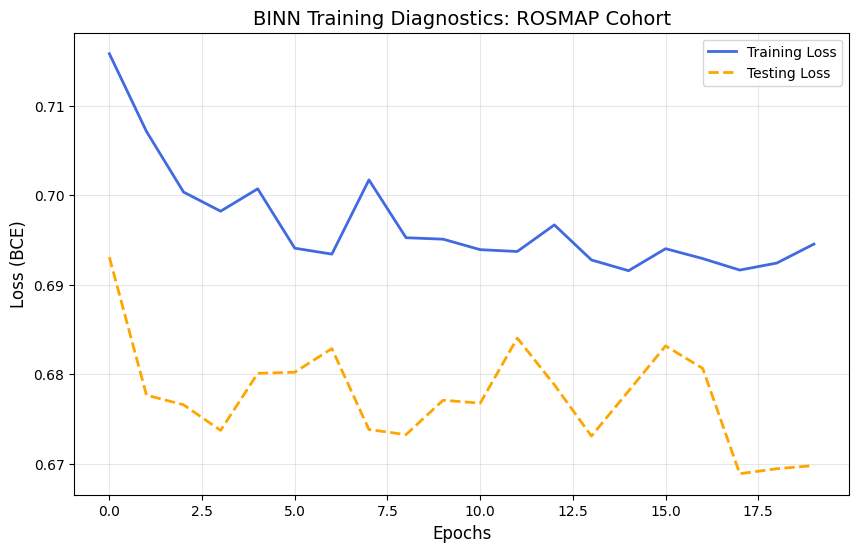

In [23]:
# Plotting
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(history['train_loss'], label='Training Loss', color='royalblue', linewidth=2)
plt.plot(history['test_loss'], label='Testing Loss', color='orange', linestyle='--', linewidth=2)

plt.title('BINN Training Diagnostics: ROSMAP Cohort', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss (BCE)', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [24]:
train_loader.dataset

AnnCollectionView object with n_obs × n_vars = 3060 × 945
    obs: 'subject', 'n_obs_aggregated', 'cell_type_high_res', 'AD_status', 'cell_type_low_res'

In [23]:
# SANITY CHECK - FROM GEMINI, only runs one one batch to check data is working
import torch
import torch.nn as nn
import torch.nn.functional as F

# --- 1. Define the simplest possible MLP ---
# This mimics your BINN's forward pass but ignores masks entirely
class ShallowMLP(nn.Module):
    def __init__(self, in_features, hidden_size):
        super().__init__()
        self.fc1 = nn.Linear(in_features, hidden_size)
        self.layer_norm = nn.LayerNorm(hidden_size)
        self.fc2 = nn.Linear(hidden_size, 1)
        self.activation = nn.LeakyReLU(0.1)

    def forward(self, x):
        x = self.fc1(x)
        x = self.layer_norm(x)
        x = self.activation(x)
        x = self.fc2(x)
        return x

# --- 2. Isolate ONE batch of data ---
# We grab the first batch and will never ask the dataloader for another one.
for batch in train_loader:
    inputs = batch.X.float().to(device)
    print(batch.obs["AD_status"])
    labels = batch.obs['AD_status'].detach().clone().float().reshape(-1, 1).to(device)
    break

print(f"Batch loaded. Inputs: {inputs.shape}, Labels: {labels.shape}")

# --- 3. Initialize Model, Optimizer, and Loss ---
model = ShallowMLP(in_features=945, hidden_size=128).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=0)
criterion = nn.BCEWithLogitsLoss()

print("--- Starting One-Batch Overfit Test ---")

# --- 4. The Overfit Loop ---
for epoch in range(150):
    model.train()
    optimizer.zero_grad()
    
    # Forward pass on the EXACT SAME batch every time
    outputs = model(inputs)
    loss = criterion(outputs, labels)
    
    loss.backward()
    
    # CRITICAL: Clip gradients to prevent the 1600+ explosion
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    
    optimizer.step()
    
    # Print progress every 10 epochs
    if epoch % 10 == 0 or epoch == 149:
        # Calculate accuracy for this specific batch
        preds = torch.sigmoid(outputs) > 0.5
        acc = (preds == labels).float().mean().item()
        
        # Check gradient norm
        grad_norm = sum(p.grad.data.norm(2).item()**2 for p in model.parameters() if p.grad is not None)**0.5
        
        print(f"Epoch {epoch:3d} | Loss: {loss.item():.4f} | Acc: {acc:.2f} | Grad Norm: {grad_norm:.2f}")

tensor([0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0])
Batch loaded. Inputs: torch.Size([16, 945]), Labels: torch.Size([16, 1])
--- Starting One-Batch Overfit Test ---
Epoch   0 | Loss: 0.8136 | Acc: 0.25 | Grad Norm: 1.00
Epoch  10 | Loss: 0.0330 | Acc: 1.00 | Grad Norm: 0.18
Epoch  20 | Loss: 0.0168 | Acc: 1.00 | Grad Norm: 0.10
Epoch  30 | Loss: 0.0098 | Acc: 1.00 | Grad Norm: 0.06
Epoch  40 | Loss: 0.0065 | Acc: 1.00 | Grad Norm: 0.04
Epoch  50 | Loss: 0.0048 | Acc: 1.00 | Grad Norm: 0.03
Epoch  60 | Loss: 0.0038 | Acc: 1.00 | Grad Norm: 0.02
Epoch  70 | Loss: 0.0031 | Acc: 1.00 | Grad Norm: 0.02
Epoch  80 | Loss: 0.0026 | Acc: 1.00 | Grad Norm: 0.02
Epoch  90 | Loss: 0.0023 | Acc: 1.00 | Grad Norm: 0.01
Epoch 100 | Loss: 0.0020 | Acc: 1.00 | Grad Norm: 0.01
Epoch 110 | Loss: 0.0017 | Acc: 1.00 | Grad Norm: 0.01
Epoch 120 | Loss: 0.0016 | Acc: 1.00 | Grad Norm: 0.01
Epoch 130 | Loss: 0.0014 | Acc: 1.00 | Grad Norm: 0.01
Epoch 140 | Loss: 0.0013 | Acc: 1.00 | Grad Norm: 0.01
Epoch

In [ ]:
import torch
print("--- Scanning DataLoader for Poison ---")
for i, batch in enumerate(train_loader):
    inputs = batch.X.float().to(device)
    labels = batch.obs['AD_status'].detach().clone().float().reshape(-1, 1).to(device)
    # 1. Check for NaNs
    if torch.isnan(inputs).any():
        print(f"CRITICAL ERROR: NaN found in inputs at batch {i}!")
        break
    
    # 2. Check for extreme outliers
    max_val = inputs.max().item()
    min_val = inputs.min().item()
    if max_val > 50.0 or min_val < -50.0:
        print(f"WARNING: Extreme values in batch {i} -> Max: {max_val:.2f}, Min: {min_val:.2f}")
        
    # 3. Check for label NaNs
    if torch.isnan(labels).any():
        print(f"CRITICAL ERROR: NaN found in labels at batch {i}!")
        break

print("Scan complete.")

--- Scanning DataLoader for Poison ---
Scan complete.


In [27]:
# SANITY CHECK - FROM GEMINI 
# Full Dataset test run
# 1. Define the model
class ShallowMLP(nn.Module):
    def __init__(self, in_features, hidden_size):
        super().__init__()
        self.fc1 = nn.Linear(in_features, hidden_size)
        self.layer_norm = nn.LayerNorm(hidden_size)
        self.fc2 = nn.Linear(hidden_size, 1)
        self.activation = nn.LeakyReLU(0.1)

    def forward(self, x):
        x = self.fc1(x)
        x = self.layer_norm(x)
        x = self.activation(x)
        x = self.fc2(x)
        return x

def train_shallow_mlp_full(train_loader, device='cpu'):
    model = ShallowMLP(in_features=945, hidden_size=128).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=0)
    criterion = nn.BCEWithLogitsLoss()

    print(f"--- Starting Full Dataset Training ---")
    
    for epoch in range(75):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for batch in train_loader:
            inputs = batch.X.float().to(device)
            labels = batch.obs['AD_status'].detach().clone().float().reshape(-1, 1).to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            preds = torch.sigmoid(outputs) > 0.5
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        epoch_loss = running_loss / total
        epoch_acc = correct / total
        print(f"Epoch {epoch:2d} | Train Loss: {epoch_loss:.4f} | Train Acc: {epoch_acc:.4f}")

# Run the function
train_shallow_mlp_full(train_loader, device=device)

--- Starting Full Dataset Training ---
Epoch  0 | Train Loss: 0.7052 | Train Acc: 0.5088
Epoch  1 | Train Loss: 0.7043 | Train Acc: 0.5203
Epoch  2 | Train Loss: 0.6981 | Train Acc: 0.5049
Epoch  3 | Train Loss: 0.7001 | Train Acc: 0.5199
Epoch  4 | Train Loss: 0.6983 | Train Acc: 0.5239
Epoch  5 | Train Loss: 0.6978 | Train Acc: 0.5242
Epoch  6 | Train Loss: 0.6927 | Train Acc: 0.5258
Epoch  7 | Train Loss: 0.6955 | Train Acc: 0.5157
Epoch  8 | Train Loss: 0.6929 | Train Acc: 0.5304
Epoch  9 | Train Loss: 0.6962 | Train Acc: 0.5297
Epoch 10 | Train Loss: 0.6959 | Train Acc: 0.5271
Epoch 11 | Train Loss: 0.6957 | Train Acc: 0.5186
Epoch 12 | Train Loss: 0.6951 | Train Acc: 0.5219
Epoch 13 | Train Loss: 0.6924 | Train Acc: 0.5395
Epoch 14 | Train Loss: 0.6916 | Train Acc: 0.5444
Epoch 15 | Train Loss: 0.6934 | Train Acc: 0.5206
Epoch 16 | Train Loss: 0.6911 | Train Acc: 0.5356
Epoch 17 | Train Loss: 0.6935 | Train Acc: 0.5229
Epoch 18 | Train Loss: 0.6891 | Train Acc: 0.5425
Epoch 19 | 